# Alzheimer's Disease Detection using MRI Images
### Multi-Class Classification | Beginner Friendly

**Classes:** Non Demented | Very Mild Demented | Mild Demented | Moderate Demented

**Models:** CNN | MLP | VGG16 | ResNet50 | EfficientNetB0 | MobileNetV2

---
## Step 1 — Problem Analysis
Understanding what we are solving before writing any code.

### What is Alzheimer's Disease?
Alzheimer's is a brain disease that slowly destroys memory and thinking skills.
Doctors use **MRI brain scans** to detect how severe the damage is.

### What is our goal?
We want to build a model that looks at an MRI image and automatically classifies it into one of 4 stages:
- **Non Demented** — healthy brain, no signs of Alzheimer's
- **Very Mild Demented** — very early signs, barely noticeable
- **Mild Demented** — clear signs of damage
- **Moderate Demented** — significant brain damage

### Why is this useful?
Early detection of Alzheimer's helps doctors start treatment sooner,
which can slow down the disease and improve the patient's quality of life.

### What kind of ML problem is this?
This is a **multi-class image classification** problem.
- Input: MRI brain scan image
- Output: one of 4 class labels
- Approach: Deep Learning using Convolutional Neural Networks (CNNs)

---
## Step 2 — Data Collection
Downloading the MRI dataset from Kaggle.

In [1]:
# Install all required libraries
!pip install -q tensorflow keras numpy pandas matplotlib seaborn scikit-learn kagglehub opencv-python

# Import everything we need
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0, MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix

print('Libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

2026-04-18 05:05:46.570726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776488746.808066      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776488746.882037      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776488747.455817      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776488747.455861      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776488747.455864      55 computation_placer.cc:177] computation placer alr

Libraries imported successfully!
TensorFlow version: 2.19.0


In [2]:
# Download the OASIS Alzheimer MRI dataset from Kaggle
import kagglehub

path = kagglehub.dataset_download('ninadaithal/imagesoasis')

# Point to the folder that contains the class subfolders
DATA_DIR = os.path.join(path, 'Data') if os.path.exists(os.path.join(path, 'Data')) else path
print(f'Dataset downloaded at: {DATA_DIR}')
print(f'Folders inside: {os.listdir(DATA_DIR)}')

Dataset downloaded at: /kaggle/input/datasets/ninadaithal/imagesoasis/Data
Folders inside: ['Non Demented', 'Very mild Dementia', 'Moderate Dementia', 'Mild Dementia']


In [3]:
# Let's see how many images are in each class
print('Image count per class:')
print('-' * 35)
total = 0
for folder in sorted(os.listdir(DATA_DIR)):
    folder_path = os.path.join(DATA_DIR, folder)
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f'  {folder:<25} : {count} images')
        total += count
print('-' * 35)
print(f'  Total images          : {total}')

Image count per class:
-----------------------------------
  Mild Dementia             : 5002 images
  Moderate Dementia         : 488 images
  Non Demented              : 67222 images
  Very mild Dementia        : 13725 images
-----------------------------------
  Total images          : 86437


---
## Step 3 — Data Cleaning
Removing corrupted images that cannot be opened.

In [5]:
# Sometimes image files get corrupted (broken/unreadable)
# We go through every image and try to open it
# If it fails, we skip it so it doesn't crash our training later

good_images  = []   # list of valid image paths
good_labels  = []   # list of their class names
bad_count    = 0    # count of corrupted images

for folder in sorted(os.listdir(DATA_DIR)):
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path):
        continue

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(folder_path, filename)

        # Try to read the image using OpenCV
        img = cv2.imread(img_path)

        if img is None:
            # Image is corrupted — skip it
            bad_count += 1
        else:
            # Image is fine — keep it
            good_images.append(img_path)
            good_labels.append(folder)

print(f'Valid images   : {len(good_images)}')
print(f'Corrupted images removed: {bad_count}')

Valid images   : 86437
Corrupted images removed: 0


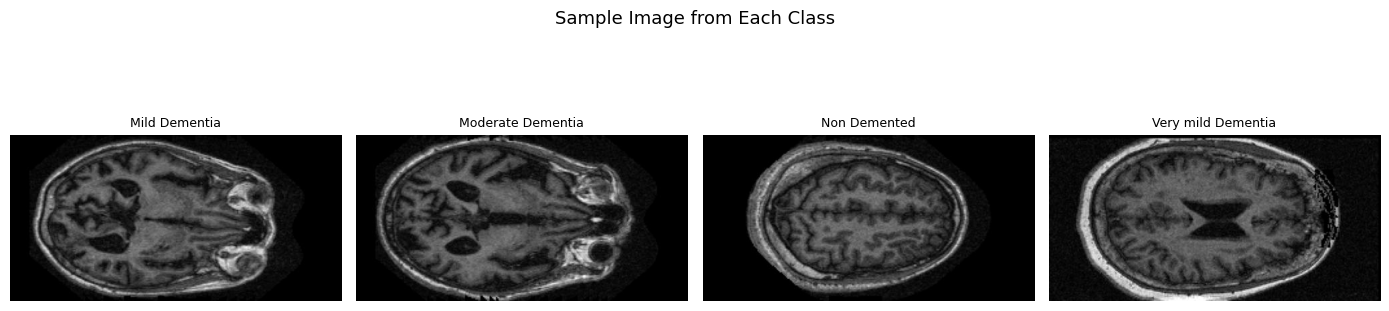

In [6]:
# Show a few sample images from each class
CLASS_NAMES = sorted(set(good_labels))
NUM_CLASSES = len(CLASS_NAMES)

plt.figure(figsize=(14, 4))
for i, class_name in enumerate(CLASS_NAMES):
    # Get first image of this class
    idx = good_labels.index(class_name)
    img = cv2.imread(good_images[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR to RGB for display

    plt.subplot(1, NUM_CLASSES, i+1)
    plt.imshow(img)
    plt.title(class_name, fontsize=9)
    plt.axis('off')

plt.suptitle('Sample Image from Each Class', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 4 — Splitting the Data
We split data into 3 sets:
- **Train (70%)** — the model learns from this
- **Validation (15%)** — used during training to check how well it's doing
- **Test (15%)** — used AFTER training to get the final score (model has never seen this)

In [7]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    good_images, good_labels,
    test_size=0.30,
    stratify=good_labels,  # make sure each class is equally represented in each split
    random_state=42
)

# Second split: split the 30% temp into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f'Training images   : {len(X_train)}')
print(f'Validation images : {len(X_val)}')
print(f'Test images       : {len(X_test)}')

Training images   : 60505
Validation images : 12966
Test images       : 12966


In [8]:
# Copy images into train/val/test folders
# This is needed so ImageDataGenerator can read them using flow_from_directory

SPLIT_DIR = '/kaggle/working/split_data'   # change to '/kaggle/working/split_data' if using Kaggle

# Create all class folders inside train, val, test
for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

# Function to copy images into the right folder
def copy_images(paths, labels, split_name):
    for img_path, label in zip(paths, labels):
        dest = os.path.join(SPLIT_DIR, split_name, label)
        shutil.copy(img_path, dest)

copy_images(X_train, y_train, 'train')
copy_images(X_val,   y_val,   'val')
copy_images(X_test,  y_test,  'test')

print('Images copied into train / val / test folders successfully!')

Images copied into train / val / test folders successfully!


---
## Step 5 — Data Balancing
Some classes have more images than others.
If we train on imbalanced data, the model gets biased towards the bigger classes.
We fix this by calculating **class weights** — telling the model to pay more attention to smaller classes.

Training set — images per class:
-----------------------------------
  Mild Dementia             : 3501
  Moderate Dementia         : 342
  Non Demented              : 47055
  Very mild Dementia        : 9607


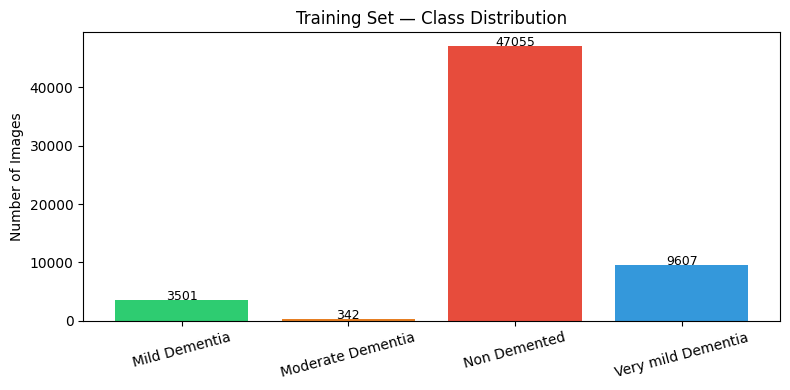

In [10]:
from sklearn.utils.class_weight import compute_class_weight

# Count images per class in training set
print('Training set — images per class:')
print('-' * 35)
for cls in CLASS_NAMES:
    count = y_train.count(cls)
    print(f'  {cls:<25} : {count}')

# Plot the class distribution as a bar chart
counts = [y_train.count(cls) for cls in CLASS_NAMES]
plt.figure(figsize=(8, 4))
bars = plt.bar(CLASS_NAMES, counts, color=['#2ecc71','#e67e22','#e74c3c','#3498db'])
plt.title('Training Set — Class Distribution')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
for bar, v in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# Compute class weights
# Classes with fewer images get a higher weight so the model pays more attention to them

# Convert class names to numbers (0, 1, 2, 3)
label_to_idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}
y_train_nums = [label_to_idx[l] for l in y_train]

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(range(NUM_CLASSES)),
    y=y_train_nums
)

# Format as dictionary {0: weight, 1: weight, ...}
class_weights = dict(enumerate(weights))

print('Class Weights (higher = more attention):')
for cls, w in zip(CLASS_NAMES, weights):
    print(f'  {cls:<25} : {w:.4f}')

Class Weights (higher = more attention):
  Mild Dementia             : 4.3206
  Moderate Dementia         : 44.2288
  Non Demented              : 0.3215
  Very mild Dementia        : 1.5745


---
## Step 6 — Training Setup
Setting up the data generators and helper functions before training.

In [12]:
# Set image size and batch size
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 20

# Training generator — applies augmentation to help the model generalize better
train_datagen = ImageDataGenerator(
    rescale=1./255,       # normalize pixel values from 0-255 to 0-1
    rotation_range=20,    # randomly rotate images
    zoom_range=0.2,       # randomly zoom in/out
    horizontal_flip=True, # randomly flip images left/right
    shear_range=0.2       # slightly distort images
)

# Validation and test generators — only normalize, NO augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}')

Found 60505 images belonging to 4 classes.
Found 12966 images belonging to 4 classes.
Found 12966 images belonging to 4 classes.
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


In [13]:
# Helper function — called after training each model
# It plots accuracy/loss, prints classification report, shows confusion matrix

def evaluate_model(model, history, model_name):

    # --- 1. Accuracy and Loss Graph ---
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'],     label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'],     label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{model_name} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # --- 2. Get predictions on test set ---
    test_generator.reset()                         # reset to start from beginning
    y_pred_probs = model.predict(test_generator)   # get prediction probabilities
    y_pred = np.argmax(y_pred_probs, axis=1)       # pick class with highest probability
    y_true = test_generator.classes                # actual true labels

    # --- 3. Classification Report ---
    # Shows precision, recall, f1-score for each class
    print(f'\n--- {model_name} — Classification Report ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # --- 4. Confusion Matrix ---
    # Shows how many images were correctly classified and where mistakes happened
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # Return test accuracy for final comparison
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    print(f'{model_name} — Test Accuracy: {test_acc:.4f}')
    return test_acc

# Store results for all models
all_results = []

print('Helper function ready! We can now train models.')

Helper function ready! We can now train models.


---
## Step 7 — Train All 6 Models

For each model we will:
1. Build the architecture
2. Compile (set optimizer + loss)
3. Train for 20 epochs
4. Evaluate (accuracy/loss graph + classification report + confusion matrix)
5. Save the model

### Model 1 — Custom CNN
A CNN uses convolutional layers to detect patterns in images.
Each layer detects more complex features — edges → shapes → parts → full objects.

In [14]:
# ── BUILD ──
cnn_model = Sequential([
    # Block 1: detect basic edges and colours
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    # Block 2: detect shapes made of edges
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Block 3: detect complex features
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),                                       # flatten 3D output to 1D
    Dense(256, activation='relu'),
    Dropout(0.5),                                    # prevent overfitting
    Dense(NUM_CLASSES, activation='softmax')         # final classification layer
])

# ── COMPILE ──
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776489778.836552      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776489778.842516      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,060 (24.86 MB)

 Trainable params: 6,517,060 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1776489782.592777     168 service.cc:152] XLA service 0x7dc2740020d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776489782.592830     168 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776489782.592836     168 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776489783.050057     168 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-18 05:23:05.014686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 05:23:05.162329: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


   3/1891 ━━━━━━━━━━━━━━━━━━━━ 2:21 75ms/step - accuracy: 0.3611 - loss: 1.7760 

I0000 00:00:1776489787.305290     168 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 194/1891 ━━━━━━━━━━━━━━━━━━━━ 3:49 136ms/step - accuracy: 0.3596 - loss: 1.4890

2026-04-18 05:23:34.665145: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 05:23:34.811599: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1891/1891 ━━━━━━━━━━━━━━━━━━━━ 280s 145ms/step - accuracy: 0.1315 - loss: 1.4162 - val_accuracy: 0.0056 - val_loss: 1.3911
Epoch 2/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 269s 142ms/step - accuracy: 0.2026 - loss: 1.3693 - val_accuracy: 0.7777 - val_loss: 1.3824
Epoch 3/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 269s 142ms/step - accuracy: 0.1283 - loss: 1.3988 - val_accuracy: 0.0578 - val_loss: 1.3867
Epoch 4/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 267s 141ms/step - accuracy: 0.0559 - loss: 1.3946 - val_accuracy: 0.7777 - val_loss: 1.3768
Epoch 5/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 266s 141ms/step - accuracy: 0.3189 - loss: 1.3514 - val_accuracy: 0.0056 - val_loss: 1.3965
Epoch 6/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 265s 140ms/step - accuracy: 0.0145 - loss: 1.3990 - val_accuracy: 0.1588 - val_loss: 1.3798
Epoch 7/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 261s 138ms/step - accuracy: 0.1443 - loss: 1.4028 - val_accuracy: 0.7777 - val_loss: 1.3798
Epoch 8/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 262s 139ms/step - accuracy: 0.2

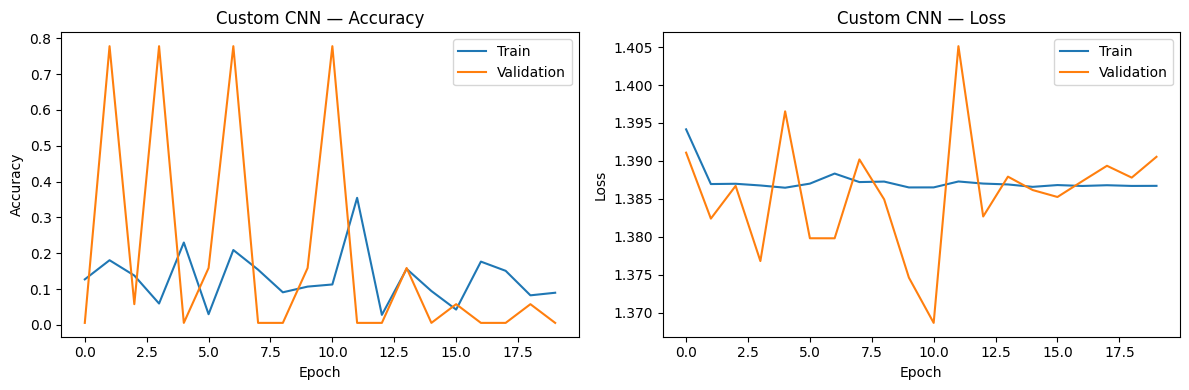

406/406 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step

--- Custom CNN — Classification Report ---
                    precision    recall  f1-score   support

     Mild Dementia       0.00      0.00      0.00       751
 Moderate Dementia       0.01      1.00      0.01        73
      Non Demented       0.00      0.00      0.00     10083
Very mild Dementia       0.00      0.00      0.00      2059

          accuracy                           0.01     12966
         macro avg       0.00      0.25      0.00     12966
      weighted avg       0.00      0.01      0.00     12966



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


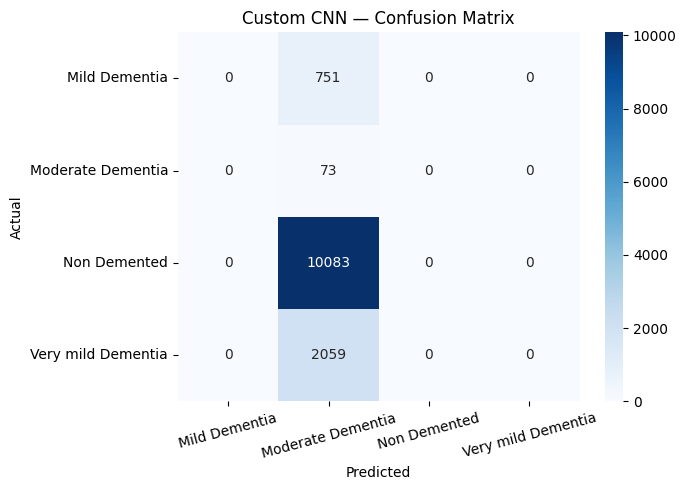

Custom CNN — Test Accuracy: 0.0056
Model saved as /kaggle/working/model_cnn.h5


In [15]:
# ── TRAIN ──
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights   # apply balancing weights
)

# ── EVALUATE ──
acc = evaluate_model(cnn_model, history_cnn, 'Custom CNN')
all_results.append({'Model': 'Custom CNN', 'Test Accuracy': round(acc, 4)})

# ── SAVE ──
cnn_model.save('/kaggle/working/model_cnn.h5')
print('Model saved as /kaggle/working/model_cnn.h5')

### Model 2 — MLP (Multi Layer Perceptron)
An MLP flattens the image into a 1D array and passes it through Dense layers.
It has no special image understanding — useful as a baseline comparison.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 262s 137ms/step - accuracy: 0.1920 - loss: 3.5592 - val_accuracy: 0.0058 - val_loss: 1.3992
Epoch 2/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 259s 137ms/step - accuracy: 0.0316 - loss: 1.3729 - val_accuracy: 0.0578 - val_loss: 1.3906
Epoch 3/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 259s 137ms/step - accuracy: 0.1124 - loss: 1.3786 - val_accuracy: 0.1588 - val_loss: 1.3852
Epoch 4/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 258s 136ms/step - accuracy: 0.2869 - loss: 1.3516 - val_accuracy: 0.0056 - val_loss: 1.3977
Epoch 5/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 251s 133ms/step - accuracy: 0.1740 - loss: 1.3477 - val_accuracy: 0.0056 - val_loss: 1.3871
Epoch 6/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 255s 135ms/step - accuracy: 0.1634 - loss: 1.3991 - val_accuracy: 0.7777 - val_loss: 1.3360
Epoch 7/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 255s 135ms/step - accuracy: 0.3703 - loss: 1.3694 - val_accuracy: 0.0056 - val_loss: 1.4076
Epoch 8/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 255s 135ms/step - ac

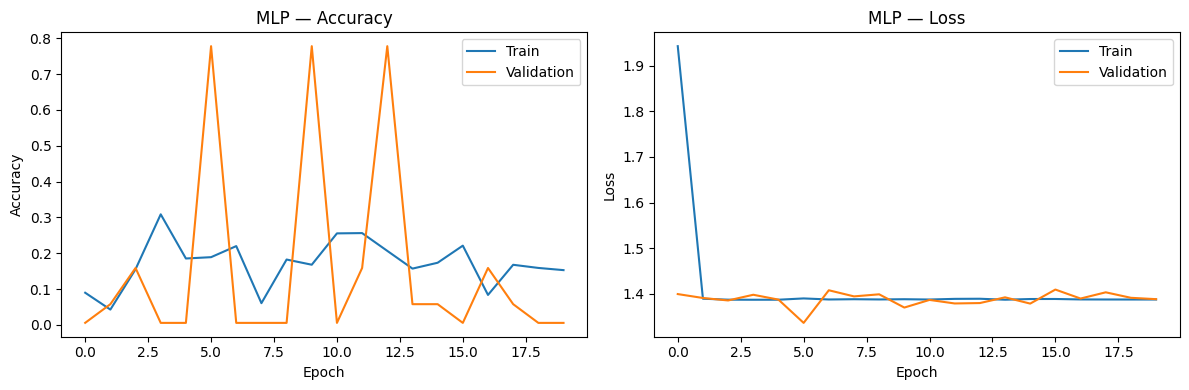

406/406 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step

--- MLP — Classification Report ---
                    precision    recall  f1-score   support

     Mild Dementia       0.00      0.00      0.00       751
 Moderate Dementia       0.01      1.00      0.01        73
      Non Demented       0.00      0.00      0.00     10083
Very mild Dementia       0.00      0.00      0.00      2059

          accuracy                           0.01     12966
         macro avg       0.00      0.25      0.00     12966
      weighted avg       0.00      0.01      0.00     12966



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


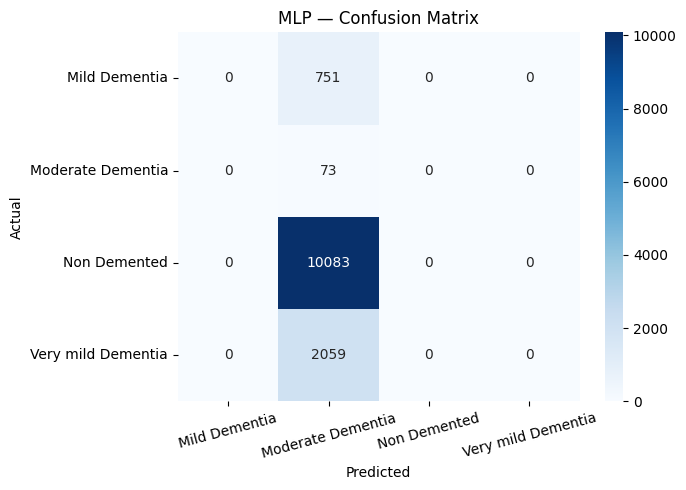

MLP — Test Accuracy: 0.0056
Model saved as /kaggle/working/model_mlp.h5


In [18]:
# ── BUILD ──
mlp_model = Sequential([
    Flatten(input_shape=(128, 128, 3)),   # flatten 128x128x3 image into 49152 numbers
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

# ── COMPILE ──
mlp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ── TRAIN ──
history_mlp = mlp_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights
)

# ── EVALUATE ──
acc = evaluate_model(mlp_model, history_mlp, 'MLP')
all_results.append({'Model': 'MLP', 'Test Accuracy': round(acc, 4)})

# ── SAVE ──
mlp_model.save('/kaggle/working/model_mlp.h5')
print('Model saved as /kaggle/working/model_mlp.h5')

### Model 3 — VGG16 (Transfer Learning)
VGG16 was trained on 1.2 million images (ImageNet).
We freeze its weights and only train our new classification head.
This is called **Transfer Learning** — reusing existing knowledge for a new task.

Epoch 1/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 283s 148ms/step - accuracy: 0.3609 - loss: 1.4024 - val_accuracy: 0.6292 - val_loss: 1.0322
Epoch 2/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 279s 148ms/step - accuracy: 0.5038 - loss: 1.2184 - val_accuracy: 0.5909 - val_loss: 1.0682
Epoch 3/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 276s 146ms/step - accuracy: 0.5299 - loss: 1.1580 - val_accuracy: 0.5904 - val_loss: 1.0326
Epoch 4/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 279s 148ms/step - accuracy: 0.5447 - loss: 1.1353 - val_accuracy: 0.6683 - val_loss: 0.8908
Epoch 5/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 278s 147ms/step - accuracy: 0.5692 - loss: 1.1109 - val_accuracy: 0.6079 - val_loss: 0.9962
Epoch 6/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 278s 147ms/step - accuracy: 0.5562 - loss: 1.0985 - val_accuracy: 0.6721 - val_loss: 0.8552
Epoch 7/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 278s 147ms/step - accuracy: 0.5761 - loss: 1.0552 - val_accuracy: 0.6647 - val_loss: 0.8721
Epoch 8/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 282s 149ms/step - ac

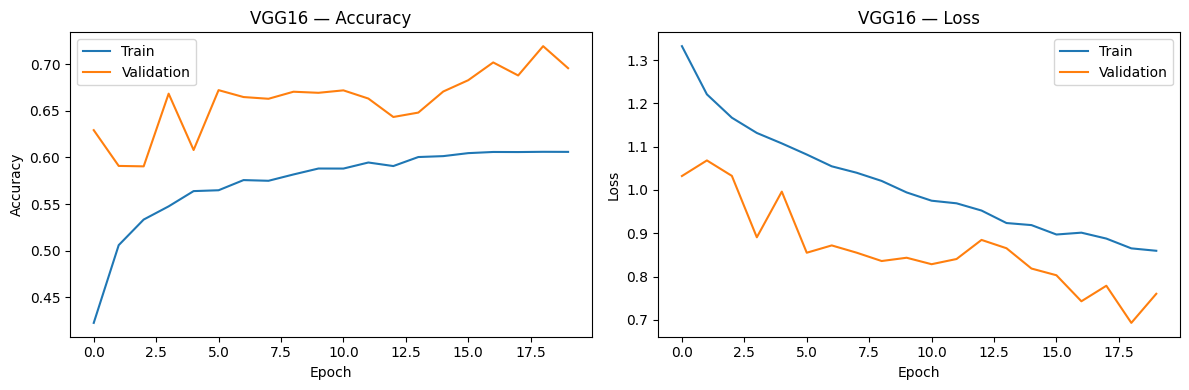

406/406 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step

--- VGG16 — Classification Report ---
                    precision    recall  f1-score   support

     Mild Dementia       0.28      0.60      0.38       751
 Moderate Dementia       0.06      0.99      0.11        73
      Non Demented       0.92      0.76      0.83     10083
Very mild Dementia       0.43      0.40      0.41      2059

          accuracy                           0.69     12966
         macro avg       0.42      0.68      0.44     12966
      weighted avg       0.80      0.69      0.73     12966



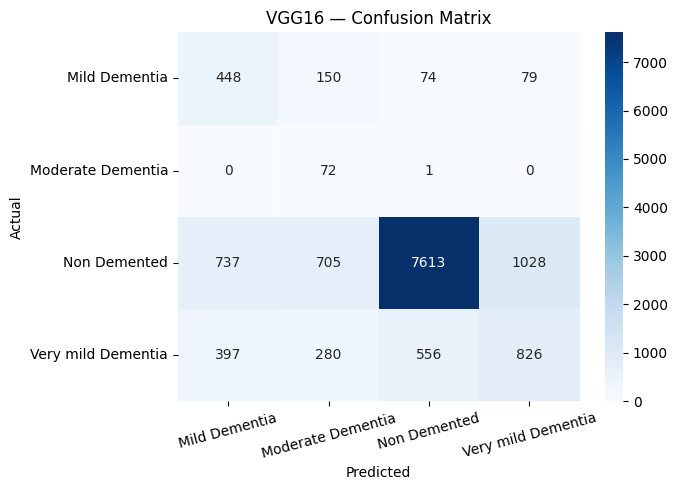

VGG16 — Test Accuracy: 0.6910
Model saved as /kaggle/working/model_vgg16.h5


In [19]:
# ── BUILD ──
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_vgg.trainable = False   # freeze all VGG16 layers — don't change their weights

vgg_model = Sequential([
    base_vgg,                                # pretrained feature extractor
    GlobalAveragePooling2D(),                # reduce to 1D
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# ── COMPILE ──
vgg_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
# Note: we use a smaller learning rate (1e-4) for pretrained models

# ── TRAIN ──
history_vgg = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights
)

# ── EVALUATE ──
acc = evaluate_model(vgg_model, history_vgg, 'VGG16')
all_results.append({'Model': 'VGG16', 'Test Accuracy': round(acc, 4)})

# ── SAVE ──
vgg_model.save('/kaggle/working/model_vgg16.h5')
print('Model saved as /kaggle/working/model_vgg16.h5')

### Model 4 — ResNet50 (Transfer Learning)
ResNet50 uses **skip connections** — it passes data directly between layers.
This solves the vanishing gradient problem and allows training very deep networks.

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 300s 153ms/step - accuracy: 0.2466 - loss: 1.4437 - val_accuracy: 0.0858 - val_loss: 1.3926
Epoch 2/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 278s 147ms/step - accuracy: 0.2826 - loss: 1.3600 - val_accuracy: 0.3772 - val_loss: 1.3352
Epoch 3/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 274s 145ms/step - accuracy: 0.3699 - loss: 1.3533 - val_accuracy: 0.3873 - val_loss: 1.3402
Epoch 4/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 271s 143ms/step - accuracy: 0.3843 - loss: 1.3519 - val_accuracy: 0.5132 - val_loss: 1.2760
Epoch 5/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 270s 143ms/step - accuracy: 0.4371 - loss: 1.3233 - val_accuracy: 0.3966 - val_loss: 1.3546
Epoch 6/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 270s 143ms/step - accuracy: 0.4428 - loss: 1.3458 - val_accuracy: 0.5918 - val_loss: 1.1385
Epoch 7/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 273s 145ms/step - accuracy: 0.4852 - loss: 1.2839 - val_accuracy: 0.4157 - val_loss: 1.3218
Epoch 8/20


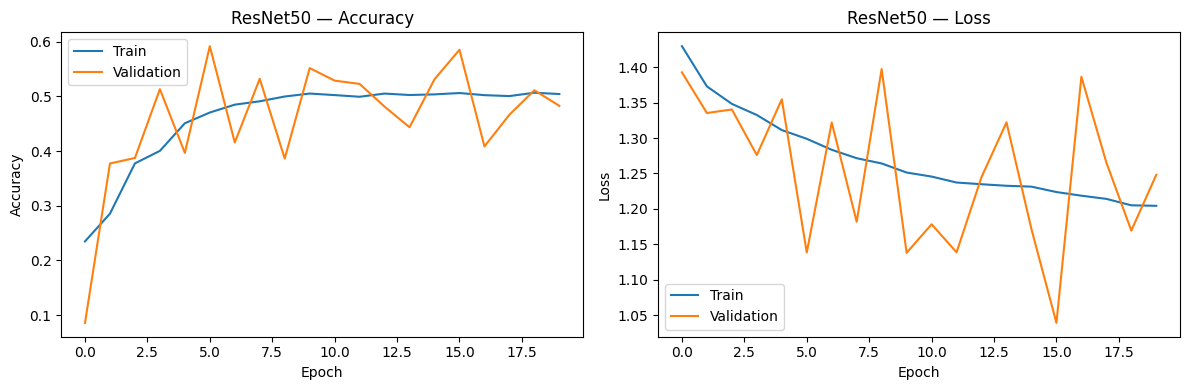

406/406 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step

--- ResNet50 — Classification Report ---
                    precision    recall  f1-score   support

     Mild Dementia       0.12      0.53      0.19       751
 Moderate Dementia       0.02      0.64      0.04        73
      Non Demented       0.88      0.54      0.67     10083
Very mild Dementia       0.27      0.10      0.14      2059

          accuracy                           0.47     12966
         macro avg       0.32      0.45      0.26     12966
      weighted avg       0.73      0.47      0.56     12966



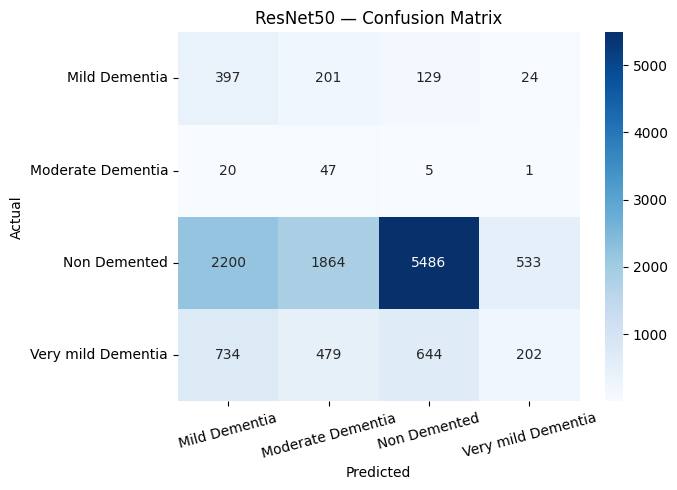

ResNet50 — Test Accuracy: 0.4729
Model saved as /kaggle/working/model_resnet50.h5


In [20]:
# ── BUILD ──
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_resnet.trainable = False

resnet_model = Sequential([
    base_resnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# ── COMPILE ──
resnet_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# ── TRAIN ──
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights
)

# ── EVALUATE ──
acc = evaluate_model(resnet_model, history_resnet, 'ResNet50')
all_results.append({'Model': 'ResNet50', 'Test Accuracy': round(acc, 4)})

# ── SAVE ──
resnet_model.save('/kaggle/working/model_resnet50.h5')
print('Model saved as /kaggle/working/model_resnet50.h5')

### Model 5 — EfficientNetB0 (Transfer Learning)
EfficientNet scales the network width, depth, and resolution together.
It achieves better accuracy with fewer parameters than older models.

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


2026-04-18 13:43:52.338161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:43:52.472671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:43:52.788448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:43:52.929615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:43:53.706188: E external/local_xla/xla/stream_

 620/1891 ━━━━━━━━━━━━━━━━━━━━ 2:46 131ms/step - accuracy: 0.2824 - loss: 1.4051

2026-04-18 13:45:28.142597: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:45:28.276727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:45:28.585282: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:45:28.726259: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:45:29.481781: E external/local_xla/xla/stream_

1891/1891 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2606 - loss: 1.4021

2026-04-18 13:48:48.002051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:48:48.135098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:48:48.433197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:48:48.573514: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:48:49.319269: E external/local_xla/xla/stream_

1891/1891 ━━━━━━━━━━━━━━━━━━━━ 317s 155ms/step - accuracy: 0.2606 - loss: 1.4021 - val_accuracy: 0.7777 - val_loss: 1.2877
Epoch 2/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 257s 136ms/step - accuracy: 0.3128 - loss: 1.4018 - val_accuracy: 0.7777 - val_loss: 1.2874
Epoch 3/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 264s 139ms/step - accuracy: 0.4752 - loss: 1.3907 - val_accuracy: 0.7777 - val_loss: 1.3715
Epoch 4/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 260s 138ms/step - accuracy: 0.3542 - loss: 1.3535 - val_accuracy: 0.0578 - val_loss: 1.3577
Epoch 5/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 261s 138ms/step - accuracy: 0.0479 - loss: 1.3708 - val_accuracy: 0.0056 - val_loss: 1.4060
Epoch 6/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 263s 139ms/step - accuracy: 0.0123 - loss: 1.3961 - val_accuracy: 0.1588 - val_loss: 1.3781
Epoch 7/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 269s 142ms/step - accuracy: 0.0415 - loss: 1.3976 - val_accuracy: 0.0093 - val_loss: 1.3895
Epoch 8/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 262s 139ms/step - accuracy: 0.0

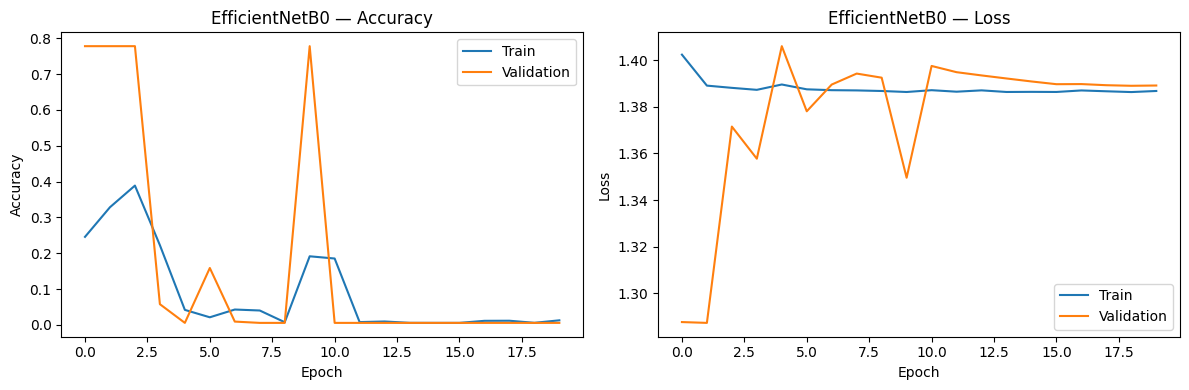

406/406 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step

--- EfficientNetB0 — Classification Report ---
                    precision    recall  f1-score   support

     Mild Dementia       0.00      0.00      0.00       751
 Moderate Dementia       0.01      1.00      0.01        73
      Non Demented       0.00      0.00      0.00     10083
Very mild Dementia       0.00      0.00      0.00      2059

          accuracy                           0.01     12966
         macro avg       0.00      0.25      0.00     12966
      weighted avg       0.00      0.01      0.00     12966



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


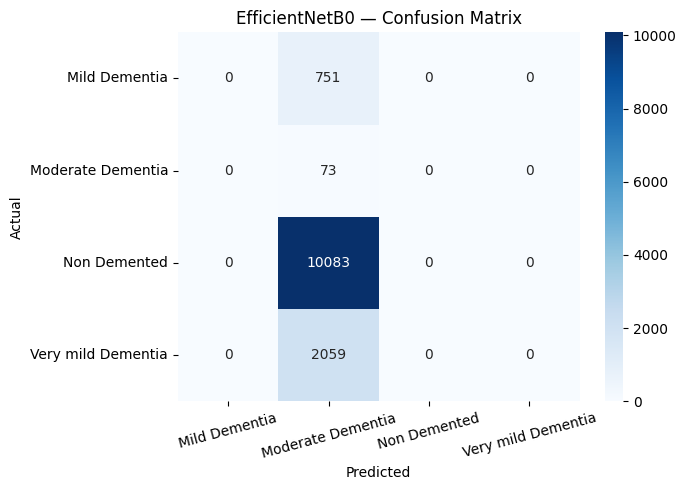

EfficientNetB0 — Test Accuracy: 0.0056
Model saved as /kaggle/working/model_efficientnet.h5


In [21]:
# ── BUILD ──
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_eff.trainable = False

eff_model = Sequential([
    base_eff,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# ── COMPILE ──
eff_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# ── TRAIN ──
history_eff = eff_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights
)

# ── EVALUATE ──
acc = evaluate_model(eff_model, history_eff, 'EfficientNetB0')
all_results.append({'Model': 'EfficientNetB0', 'Test Accuracy': round(acc, 4)})

# ── SAVE ──
eff_model.save('/kaggle/working/model_efficientnet.h5')
print('Model saved as /kaggle/working/model_efficientnet.h5')

### Model 6 — MobileNetV2 (Transfer Learning)
MobileNet is designed to be very lightweight — great for phones and edge devices.
Despite its small size, it performs surprisingly well!

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


2026-04-18 15:12:58.850899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 15:12:58.987772: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 964/1891 ━━━━━━━━━━━━━━━━━━━━ 2:02 133ms/step - accuracy: 0.4161 - loss: 1.4258

2026-04-18 15:15:15.399147: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 15:15:15.536802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1891/1891 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.4433 - loss: 1.3434

2026-04-18 15:17:44.813311: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 15:17:44.949638: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1891/1891 ━━━━━━━━━━━━━━━━━━━━ 299s 151ms/step - accuracy: 0.4433 - loss: 1.3433 - val_accuracy: 0.6588 - val_loss: 0.8867
Epoch 2/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 264s 139ms/step - accuracy: 0.5747 - loss: 1.0247 - val_accuracy: 0.5945 - val_loss: 0.9937
Epoch 3/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 264s 140ms/step - accuracy: 0.6112 - loss: 0.9185 - val_accuracy: 0.6655 - val_loss: 0.8553
Epoch 4/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 269s 142ms/step - accuracy: 0.6326 - loss: 0.8623 - val_accuracy: 0.6425 - val_loss: 0.8869
Epoch 5/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 264s 140ms/step - accuracy: 0.6479 - loss: 0.8178 - val_accuracy: 0.7092 - val_loss: 0.7317
Epoch 6/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 266s 141ms/step - accuracy: 0.6602 - loss: 0.7818 - val_accuracy: 0.6768 - val_loss: 0.8019
Epoch 7/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 268s 142ms/step - accuracy: 0.6702 - loss: 0.7303 - val_accuracy: 0.6999 - val_loss: 0.7466
Epoch 8/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 264s 140ms/step - accuracy: 0.6

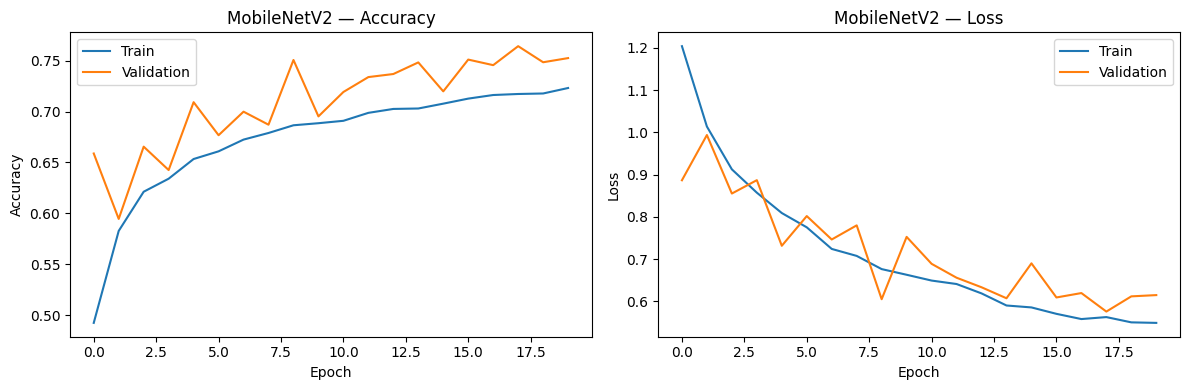

406/406 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step

--- MobileNetV2 — Classification Report ---
                    precision    recall  f1-score   support

     Mild Dementia       0.33      0.85      0.47       751
 Moderate Dementia       0.50      0.85      0.63        73
      Non Demented       0.96      0.76      0.85     10083
Very mild Dementia       0.49      0.70      0.58      2059

          accuracy                           0.75     12966
         macro avg       0.57      0.79      0.63     12966
      weighted avg       0.85      0.75      0.78     12966



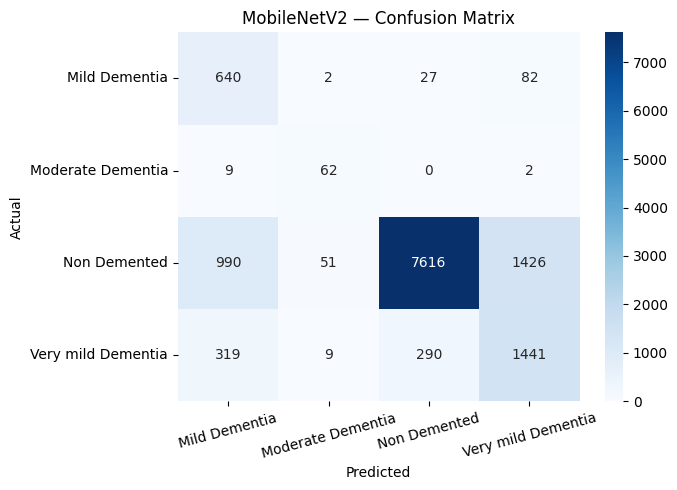

MobileNetV2 — Test Accuracy: 0.7527
Model saved as /kaggle/working/model_mobilenet.h5


In [22]:
# ── BUILD ──
base_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_mobile.trainable = False

mobile_model = Sequential([
    base_mobile,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# ── COMPILE ──
mobile_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# ── TRAIN ──
history_mobile = mobile_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights
)

# ── EVALUATE ──
acc = evaluate_model(mobile_model, history_mobile, 'MobileNetV2')
all_results.append({'Model': 'MobileNetV2', 'Test Accuracy': round(acc, 4)})

# ── SAVE ──
mobile_model.save('/kaggle/working/model_mobilenet.h5')
print('Model saved as /kaggle/working/model_mobilenet.h5')

---
## Step 8 — Final Model Comparison
Which model performed the best?

In [2]:
# Create a summary table
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print('===============================')
print('    Final Model Comparison')
print('===============================')
print(results_df.to_string(index=False))
print('===============================')

# Bar chart of all models
plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.bar(results_df['Model'], results_df['Test Accuracy'], color=colors)
plt.title('Test Accuracy — All Models (Gold = Best)')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.1)
for bar, val in zip(bars, results_df['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f"Best Model : {best['Model']}")
print(f"Test Accuracy : {best['Test Accuracy']}")

NameError: name 'pd' is not defined

In [1]:
# ── PREDICT A SINGLE IMAGE ──
# Use this after training to test your model on a new MRI image

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load whichever model you want to use
model = load_model('/kaggle/working/model_mobilenet.h5')  # change filename as needed

def predict_image(img_path):
    # Load and resize image
    img = image.load_img(img_path, target_size=(128, 128))

    # Convert to array and normalize
    img_array = image.img_to_array(img) / 255.0

    # Add batch dimension — model expects shape (1, 128, 128, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction  = model.predict(img_array)
    class_index = np.argmax(prediction)        # index of highest probability
    confidence  = prediction[0][class_index] * 100
    label       = CLASS_NAMES[class_index]

    print(f'Predicted Class : {label}')
    print(f'Confidence      : {confidence:.2f}%')

# Usage:
# predict_image('/path/to/your/mri_image.jpg')

2026-04-18 17:57:23.341114: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776535043.547138      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776535043.613710      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776535044.111119      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776535044.111169      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776535044.111172      55 computation_placer.cc:177] computation placer alr

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/kaggle/working/model_mobilenet.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)